# FC reconfiguration and working-memory performance (dataset B)

**Goutham's `per_analysis` pipeline, run on Finalist B.** FC per condition → reconfiguration
(`2bk − 0bk`) → collapse to a 12-network fingerprint → cross-validated prediction of WM performance,
plus a triple-network check. On A it was a real negative (fingerprint r = −0.015).

**The modelling code is Goutham's, unchanged** — only the data access is swapped, so the same pipeline
runs on either dataset. The three swaps (all data access):

| Goutham (A only) | here (A and B) |
|---|---|
| `np.loadtxt("subjects_list.txt")` | `ds.load_subjects(spec)` |
| `get_condition_signals`, `WM/tfMRI_WM` paths | `condition_signals(spec, ...)`, same frames and `delay = 4.0` |
| `get_resilience`, `Stats.txt` | `pp.behaviour_table(spec)["acc_2bk"]`, plus d' from `wm.csv` |

**One post-audit fix (2026-07-17), reporting only** — the permutation-null p-value now uses the
`(#exceed+1)/(N+1)` floor (see cell 5 change-log). It changes no r/R², and §1 validates A with the null
disabled, so Goutham's reproduced dataset-A numbers stand.

**Headline honesty** — the held-out r is ≈ 0.31, not the seed-42 0.41. For `acc_2bk` much of it is
general ability and trait FC; d' is the more robust target.

In [1]:
# --- Setup: shared A/B layer + data dir (same pattern as the other sandbox notebooks) ---
from pathlib import Path
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, norm

cwd = Path.cwd().resolve()
JAIME = cwd if (cwd / "datasets.py").exists() else cwd / "sandbox" / "jaime"
ROOT = JAIME.parents[1]                                # the-gammas repo root
sys.path.insert(0, str(JAIME))
import datasets as ds, preprocessing as pp, evaluation as ev

DATA   = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))
A, B   = ds.spec_a(DATA), ds.spec_b(DATA)              # the only A/B switch in the whole notebook
N_PERM = int(os.environ.get("GAMMAS_NPERM", "1000"))   # permutations for the null

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print(A.name, "|", B.name)

Finalist A (100 subj, task-only) | Finalist B (339 subj, +resting-state)


In [2]:
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# ----- Goutham's functions, unchanged -----
def connect_dots(brain_waves):
    return np.corrcoef(brain_waves)

def get_brain_profile(brain_shift, network_names, societies):
    fingerprint = []
    for i, group_a in enumerate(societies):
        indices_a = np.where(network_names == group_a)[0]
        for group_b in societies[i:]:
            indices_b = np.where(network_names == group_b)[0]
            if len(indices_a) == 0 or len(indices_b) == 0:
                fingerprint.append(0.0); continue
            if group_a == group_b:
                sub = brain_shift[np.ix_(indices_a, indices_a)]; n = sub.shape[0]
                val = sub[np.triu_indices(n, k=1)].mean() if n > 1 else 0.0
            else:
                val = brain_shift[np.ix_(indices_a, indices_b)].mean()
            fingerprint.append(val)
    return fingerprint

In [3]:
# swap 1+2 -- REPLACES his get_task_frames + get_condition_signals (A-only WM/tfMRI_WM paths).
# Same frames, same delay=4.0 HRF shift; only the paths come from `ds`, so it runs on A and B.
def condition_signals(spec, subject, level, delay=4.0):
    conds = ds.COND_0BACK if level == "0back" else ds.COND_2BACK
    mats = []
    for run in (0, 1):
        ts = ds.load_timeseries(spec, subject, run)          # A: WM/tfMRI_WM_{LR,RL} . B: bold7/bold8
        if spec.kind == "A":
            ev_dir = spec.task_dir/"subjects"/subject/"WM"/f"tfMRI_WM_{ds.RUN_LABELS['A'][run]}"/"EVs"
        else:
            ev_dir = spec.task_dir/"subjects"/subject/"EVs"/f"tfMRI_WM_{ds.RUN_LABELS['B'][run]}"
        frames = []
        for cond in conds:
            ev = np.loadtxt(ev_dir/f"{cond}.txt", ndmin=2)
            for onset, duration, _ in ev:
                start = int(np.floor((onset + delay) / ds.TR))
                frames.append(np.arange(start, start + int(np.ceil(duration / ds.TR))))
        frames = np.unique(np.concatenate(frames))
        frames = frames[frames < ts.shape[1]]
        mats.append(ts[:, frames])
    return np.concatenate(mats, axis=1)

# swap 3 -- REPLACES his get_resilience (Stats.txt reader, A-only).
# acc_2bk from the shared behaviour layer (A & B); d' from wm.csv (B only).
def get_scores(spec, subjects, target="acc"):
    if target == "acc":
        beh = pp.behaviour_table(spec).set_index("subject")
        return beh.loc[subjects, "acc_2bk"].to_numpy(float)
    sd  = pp.signal_detection_table(spec).set_index("subject")            # B only
    hit = np.clip(sd.loc[subjects, "hit_2bk"].to_numpy(float), 1/32,  1 - 1/32)
    fa  = np.clip(sd.loc[subjects, "fa_2bk"].to_numpy(float),  1/128, 1 - 1/128)
    return norm.ppf(hit) - norm.ppf(fa)      # d' -- 1/2N extreme-rate correction, verified in section 4

In [4]:
_FEAT = {}
def measure_all_chemistry(spec):
    # REPLACES his subjects_list.txt loop -> ds.load_subjects; the rest (corrcoef, 2bk-0bk) is his.
    if spec.kind in _FEAT:
        return _FEAT[spec.kind]
    net       = np.load(spec.task_dir / "regions.npy").T[1]     # raw network labels, as he uses them
    societies = np.unique(net)
    subjects  = ds.load_subjects(spec)
    fps, contrasts = [], []
    for s in subjects:
        calm = condition_signals(spec, s, "0back")
        busy = condition_signals(spec, s, "2back")
        brain_shift = connect_dots(busy) - connect_dots(calm)   # 2bk - 0bk  FC reconfiguration
        fps.append(get_brain_profile(brain_shift, net, societies))
        contrasts.append(busy.mean(1) - calm.mean(1))           # 2bk - 0bk  activation (for triple-net)
    _FEAT[spec.kind] = (subjects, np.array(fps), np.array(contrasts), net)
    return _FEAT[spec.kind]

In [5]:
def cv_predict(X, y, model_fn, seed=42):
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)      # his split (seed exposed for section 2)
    pred = np.zeros_like(y, dtype=float)
    for tr, te in cv.split(X):
        sc = StandardScaler().fit(X[tr])                        # fit on train only (no leakage)
        m  = model_fn().fit(sc.transform(X[tr]), y[tr])
        pred[te] = m.predict(sc.transform(X[te]))
    return pred

def perm_null(X, y, model_fn, obs_r, obs_r2, n=N_PERM):
    # CHANGE-LOG (2026-07-17, post-audit) -- p-value REPORTING correction, Goutham-provenance note:
    # the one-sided permutation p now uses the (#exceed + 1)/(n + 1) estimator instead of the raw
    # exceedance mean. A Monte-Carlo permutation p can never be exactly 0; its floor is 1/(n+1), and
    # the +1 counts the observed statistic among the permutations (Phipson & Smyth 2010; Avery 2020
    # likewise reports P = 1/1001). This touches ONLY the reported p -- Goutham's replicated modelling
    # (fingerprint, KFold, RidgeCV, r/R2) is unchanged, and section 1 validates A with null=False, so
    # his reproduced dataset-A numbers are unaffected.
    rng = np.random.default_rng(0)
    nr, nr2 = np.empty(n), np.empty(n)
    for i in range(n):
        yp = rng.permutation(y)
        pr = cv_predict(X, yp, model_fn)
        nr[i], nr2[i] = pearsonr(pr, yp)[0], r2_score(yp, pr)
    return ((nr >= obs_r).sum() + 1) / (n + 1), ((nr2 >= obs_r2).sum() + 1) / (n + 1), nr

crystal_ball = lambda: RidgeCV(alphas=np.logspace(-3, 5, 100))   # his model

def predict_the_future(spec, target="acc", null=True):
    # his fingerprint -> RidgeCV -> held-out prediction; only the X/y sourcing changed.
    subjects, X, _contrast, _net = measure_all_chemistry(spec)
    y = get_scores(spec, subjects, target)
    pred = cv_predict(X, y, crystal_ball)
    r, r2 = pearsonr(pred, y)[0], r2_score(y, pred)
    p_r, p_r2, null_r = perm_null(X, y, crystal_ball, r, r2) if null else (np.nan, np.nan, None)
    return dict(method="fingerprint", data=spec.kind, target=target, n=len(y),
                r=r, r2=r2, p_r=p_r, p_r2=p_r2, pred=pred, y=y, null_r=null_r)

def run_triple_network_check(spec, target="acc", null=True):
    # his triple-network (salience / FPN / DMN activation) -> LinearRegression; same three swaps.
    subjects, _X, contrast, net = measure_all_chemistry(spec)
    salience  =  contrast[:, np.where(net == "Cingulo-Oper")[0]].mean(1)
    fpn       =  contrast[:, np.where(net == "Frontopariet")[0]].mean(1)
    dmn_supp  = -contrast[:, np.where(net == "Default")[0]].mean(1)
    switching = fpn + dmn_supp
    X = np.column_stack([salience, switching])
    y = get_scores(spec, subjects, target)
    pred = cv_predict(X, y, LinearRegression)
    r, r2 = pearsonr(pred, y)[0], r2_score(y, pred)
    p_r, p_r2, null_r = perm_null(X, y, LinearRegression, r, r2) if null else (np.nan, np.nan, None)
    return dict(method="triple-network", data=spec.kind, target=target, n=len(y),
                r=r, r2=r2, p_r=p_r, p_r2=p_r2, pred=pred, y=y, null_r=null_r,
                diag=dict(sal_fpn=pearsonr(salience, fpn)[0], sal_dmn=pearsonr(salience, dmn_supp)[0],
                          switch_acc=pearsonr(switching, get_scores(spec, subjects, "acc"))[0]))

## 1. Validation on A

Running the port on A must return Goutham's numbers: fingerprint r = -0.0150, triple-network
r = 0.0760; triple diagnostics salience-FPN +0.755, salience-DMN -0.820, switching-acc +0.183.

In [6]:
a_fp = predict_the_future(A, "acc", null=False)
a_tr = run_triple_network_check(A, "acc", null=False)
print(f"fingerprint -> acc : r={a_fp['r']:+.4f}  R2={a_fp['r2']:+.4f}    (Goutham: r=-0.0150)")
print(f"triple-net  -> acc : r={a_tr['r']:+.4f}  R2={a_tr['r2']:+.4f}    (Goutham: r=+0.0760)")
d = a_tr["diag"]
print(f"triple diag       : salience-FPN {d['sal_fpn']:+.3f}   salience-DMN {d['sal_dmn']:+.3f}   "
      f"switching-acc {d['switch_acc']:+.3f}")
print( "                    (Goutham:     +0.755                -0.820                 +0.183)")

fingerprint -> acc : r=-0.0150  R2=-0.0353    (Goutham: r=-0.0150)
triple-net  -> acc : r=+0.0760  R2=-0.0080    (Goutham: r=+0.0760)
triple diag       : salience-FPN +0.755   salience-DMN -0.820   switching-acc +0.183
                    (Goutham:     +0.755                -0.820                 +0.183)


## 2. Result on B (336 subjects)

Same method, more subjects, plus d'. The `p` columns are one-sided permutation p-values (the null is
centred below 0, so no leakage). The `r` here is a single seed-42 realisation; section 2b shows how
much that flatters it.

In [7]:
rows = [predict_the_future(A, "acc"),        run_triple_network_check(A, "acc"),
        predict_the_future(B, "acc"),        run_triple_network_check(B, "acc"),
        predict_the_future(B, "dprime"),     run_triple_network_check(B, "dprime")]

results = pd.DataFrame([{k: r[k] for k in ("data","method","target","n","r","r2","p_r","p_r2")} for r in rows])
results.round(3)

,data,method,target,n,r,r2,p_r,p_r2
0,A,fingerprint,acc,100,-0.015,-0.035,0.167,0.498
1,A,triple-network,acc,100,0.076,-0.008,0.121,0.099
2,B,fingerprint,acc,336,0.405,0.162,0.001,0.001
3,B,triple-network,acc,336,0.371,0.137,0.001,0.001
4,B,fingerprint,dprime,336,0.399,0.158,0.001,0.001
5,B,triple-network,dprime,336,0.347,0.120,0.001,0.001


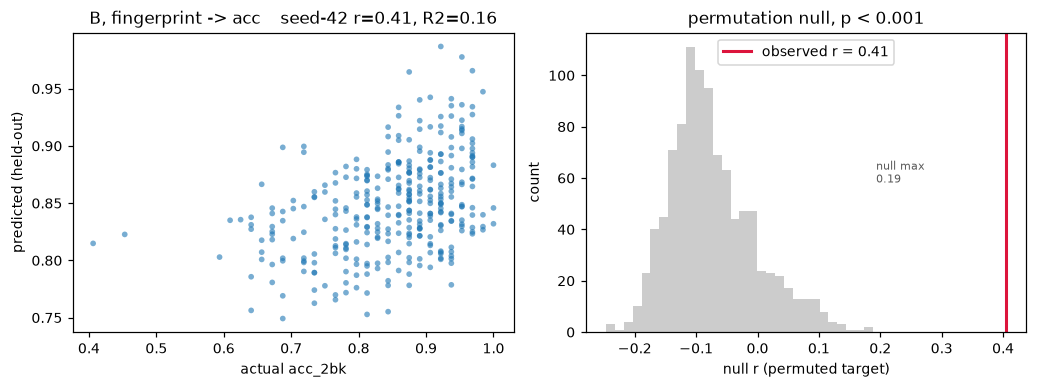

In [8]:
# predicted-vs-actual (the signal) + the permutation null (the arbiter) -- B, fingerprint -> acc
b_fp = next(r for r in rows if r["data"]=="B" and r["method"]=="fingerprint" and r["target"]=="acc")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax1.scatter(b_fp["y"], b_fp["pred"], s=14, alpha=.6, edgecolor="none")
ax1.set(xlabel="actual acc_2bk", ylabel="predicted (held-out)",
        title=f"B, fingerprint -> acc    seed-42 r={b_fp['r']:.2f}, R2={b_fp['r2']:.2f}")
ax2.hist(b_fp["null_r"], bins=30, color="0.8")
ax2.axvline(b_fp["r"], color="crimson", lw=2, label=f"observed r = {b_fp['r']:.2f}")
ax2.text(b_fp["null_r"].max()+0.005, ax2.get_ylim()[1]*0.5, f"null max\n{b_fp['null_r'].max():.2f}",
         fontsize=7, color="0.35")
# permutation p has a floor of 1/(N_PERM+1); show "< 0.001" there rather than a spurious "= 0.000"
p_disp = "< 0.001" if b_fp["p_r"] <= 1/(N_PERM + 1) + 1e-12 else f"= {b_fp['p_r']:.3f}"
ax2.set(xlabel="null r (permuted target)", ylabel="count", title=f"permutation null, p {p_disp}")
ax2.legend()
plt.tight_layout(); plt.show()

## 2b. Stability of r

At n = 336 with 78 features, one CV split is a wide draw and seed 42 sits near the top. Repeated CV
gives the central effect; a single 80/20 held-out split is the least optimistic, and the number to
report.

In [9]:
# pull B features and targets once for the analyses in sections 2b and 3
subs_b, Xb, contr_b, net_b = measure_all_chemistry(B)
y_acc = get_scores(B, subs_b, "acc")
y_dp  = get_scores(B, subs_b, "dprime")
pred_acc = cv_predict(Xb, y_acc, crystal_ball)          # seed-42 out-of-fold fingerprint -> acc

def repeated_cv_r(X, y, model_fn, n_seeds=20):
    # 5-fold CV repeated over n_seeds partitions; a stable effect size instead of one draw.
    rs = []
    for seed in range(n_seeds):
        rs.append(pearsonr(cv_predict(X, y, model_fn, seed=seed), y)[0])
    return np.array(rs)

rs = repeated_cv_r(Xb, y_acc, crystal_ball, 20)

split = ev.make_split(B)                                 # leakage-safe subject split (80/20)
pos = {s: i for i, s in enumerate(subs_b)}
tr = [pos[s] for s in split["train"] if s in pos]
te = [pos[s] for s in split["test"]  if s in pos]
sc = StandardScaler().fit(Xb[tr])
r_hold = pearsonr(crystal_ball().fit(sc.transform(Xb[tr]), y_acc[tr]).predict(sc.transform(Xb[te])), y_acc[te])[0]

print(f"HEADLINE  held-out (n={len(te)})          : r = {r_hold:.2f}")
print(f"central   repeated CV (20 seeds)         : r = {rs.mean():.2f} +/- {rs.std():.2f}  "
      f"[{rs.min():.2f}, {rs.max():.2f}]")
print(f"optimistic seed-42 (table above)         : r = {pearsonr(pred_acc, y_acc)[0]:.2f}  "
      f"<- one draw, do not headline")

HEADLINE  held-out (n=67)          : r = 0.31
central   repeated CV (20 seeds)         : r = 0.37 +/- 0.02  [0.29, 0.40]
optimistic seed-42 (table above)         : r = 0.41  <- one draw, do not headline


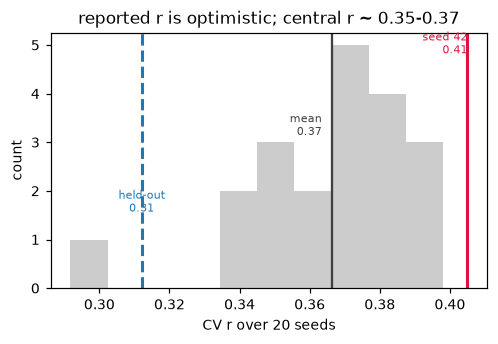

In [10]:
# seed-optimism at a glance
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.hist(rs, bins=10, color="0.8", edgecolor="none")
ax.axvline(rs.mean(),  color="0.25", lw=1.5)
ax.axvline(0.405,      color="crimson", lw=2)
ax.axvline(r_hold,     color="tab:blue", lw=2, ls="--")
top = ax.get_ylim()[1]
ax.text(0.405,  top*0.92, "seed 42\n0.41",  color="crimson",  fontsize=7, ha="right")
ax.text(rs.mean()-0.003, top*0.60, f"mean\n{rs.mean():.2f}", color="0.25", fontsize=7, ha="right")
ax.text(r_hold, top*0.30, f"held-out\n{r_hold:.2f}", color="tab:blue", fontsize=7, ha="center")
ax.set(xlabel="CV r over 20 seeds", ylabel="count", title="reported r is optimistic; central r ~ 0.35-0.37")
plt.tight_layout(); plt.show()

## 3. Specificity of the effect

The result beats the null, so it is real. Three checks show it is less specific than "the
reconfiguration predicts working memory".

### 3a. Trait FC vs reconfiguration

The same fingerprint built from 0bk-only FC, 2bk-only FC, and their difference. If a single static
state already predicts, reconfiguration is not doing all the work.

0back     FC -> acc :  r = +0.287
2back     FC -> acc :  r = +0.276
reconfig  FC -> acc :  r = +0.405


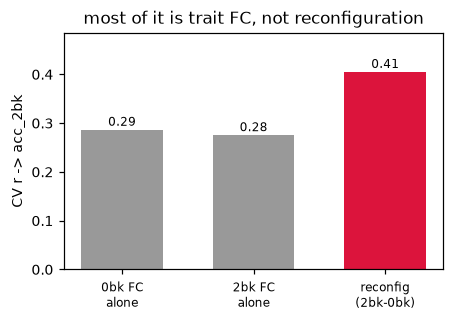

In [11]:
def fingerprints_by_state(spec):
    # 78-dim fingerprints from 0bk-only FC, 2bk-only FC, and (2bk - 0bk). Reuses his functions verbatim;
    # 'reconfig' must equal the model features.
    net = np.load(spec.task_dir / "regions.npy").T[1]; societies = np.unique(net)
    fp0, fp2, fpd = [], [], []
    for s in ds.load_subjects(spec):
        calm, busy = condition_signals(spec, s, "0back"), condition_signals(spec, s, "2back")
        c0, c2 = connect_dots(calm), connect_dots(busy)
        fp0.append(get_brain_profile(c0, net, societies))
        fp2.append(get_brain_profile(c2, net, societies))
        fpd.append(get_brain_profile(c2 - c0, net, societies))
    return {"0back": np.array(fp0), "2back": np.array(fp2), "reconfig": np.array(fpd)}

fps = fingerprints_by_state(B)
assert np.allclose(fps["reconfig"], Xb), "reconfig fingerprint must equal the model features"
trait = {k: pearsonr(cv_predict(v, y_acc, crystal_ball), y_acc)[0] for k, v in fps.items()}
for k in ("0back", "2back", "reconfig"):
    print(f"{k:9s} FC -> acc :  r = {trait[k]:+.3f}")

fig, ax = plt.subplots(figsize=(4.2, 3))
labels = ["0bk FC\nalone", "2bk FC\nalone", "reconfig\n(2bk-0bk)"]
vals = [trait["0back"], trait["2back"], trait["reconfig"]]
ax.bar(range(3), vals, color=["0.6", "0.6", "crimson"], width=0.62)
for x, v in zip(range(3), vals): ax.text(x, v+0.008, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=8)
ax.set(ylabel="CV r -> acc_2bk", ylim=(0, max(vals)+0.08), title="most of it is trait FC, not reconfiguration")
plt.tight_layout(); plt.show()

The multivariate reconfiguration fingerprint predicts best (0.41 seed-42 / 0.37 repeated-CV), but each
single static state already carries most of it (0bk 0.29, 2bk 0.28) — reconfiguration adds over trait
FC, it is not a separate mechanism.

In [12]:
# ADDED 2026-07-17 (post-audit): apples-to-apples analog of Avery 2020.
# Avery used UNDIFFERENCED whole-task n-back FC; our headline uses the 2bk-0bk difference. Building one
# FC over all n-back frames (0bk + 2bk) with the same fingerprint + RidgeCV is the comparable number.
# Reuses Goutham's connect_dots / get_brain_profile unchanged; only the frame pooling is new.
def _pooled_task_fp(spec, subjects, net, soc):
    out = []
    for s in subjects:
        allframes = np.concatenate([condition_signals(spec, s, "0back"),
                                    condition_signals(spec, s, "2back")], axis=1)
        out.append(get_brain_profile(connect_dots(allframes), net, soc))
    return np.array(out)

_net = np.load(B.task_dir / "regions.npy").T[1]; _soc = np.unique(_net)
_Xpool = _pooled_task_fp(B, subs_b, _net, _soc)
_rp = np.array([pearsonr(cv_predict(_Xpool, y_acc, crystal_ball, seed=s), y_acc)[0] for s in range(20)])
print(f"Avery analog (undifferenced whole-task FC) -> acc : repeated-CV r = {_rp.mean():.3f} +/- {_rp.std():.3f}")
print(f"  vs Avery r=0.36 (10-fold CV, undifferenced task FC); vs the 2bk-0bk difference fingerprint r~0.37")
# expected: ~0.278 +/- 0.025

Avery analog (undifferenced whole-task FC) -> acc : repeated-CV r = 0.278 +/- 0.025
  vs Avery r=0.36 (10-fold CV, undifferenced task FC); vs the 2bk-0bk difference fingerprint r~0.37


### 3b. Reliability of the reconfiguration score  <!-- ADDED 2026-07-17 · automated literature review; REFRAMED post-audit -->

**The puzzle.** The scalar summary of reconfiguration barely predicts (integration index r≈0.04, §4),
yet each single-condition fingerprint does (0bk repeated-CV r≈0.27). Does the load *change* carry no
individual signal? We check the reliability of the `2bk−0bk` score.

**Why a difference score can fail.** It subtracts two correlated conditions, removing the true-score
variance they share and leaving mostly error (Hedge et al. 2018) — which sinks a single scalar contrast.

Between-run (LR vs RL) reliability over the 336 subjects, two ways:

| fingerprint | feature-wise r (Fisher-mean [median, IQR]) | subject-ID across runs (chance ≈ 0.003) |
|---|---|---|
| 0-back FC | +0.33 [+0.35, 0.30–0.37] | 0.031 |
| 2-back FC | +0.33 [+0.34, 0.30–0.38] | 0.031 |
| **reconfig (2bk − 0bk)** | **+0.02 [+0.02, −0.00–0.05]** | **0.006** |

**Reading it:**
- The change score's *individual features* barely reproduce across runs (feature-wise r≈0.02), and it
  cannot tell subjects apart across runs (ID ≈ chance) — each single condition reaches ~10× chance.
- **But low feature-wise reliability ≠ the pattern fails to predict.** A multivariate model aggregates
  weak-but-consistent signal across many edges, so the 78-dim fingerprint still predicts out-of-sample
  under the strictest test: train on one run, test on the OTHER → cross-run r≈0.28 (cell below), tied
  with single conditions.
- Difference-score attenuation (Hedge 2018) *does* bite — but on the **scalar** directional summaries
  (integration index r≈0.04, §4), not the pattern.

**Bottom line:** the raw edges of the difference are noisy; the multivariate pattern is not.
*(LR/RL also differ in phase-encoding, so feature-wise reliability is a conservative lower bound.)*

In [13]:
# ADDED 2026-07-17 (literature review): reliability of the change-score vs its conditions.
# Two views of between-run (LR vs RL) reliability: (i) feature-wise test-retest (Fisher-z averaged,
# with distribution), (ii) multivariate subject identification across runs (chance = 1/N).
# Reuses this notebook's connect_dots / get_brain_profile; ~4 s on 336 subjects.
def _cond_run(spec, subject, run, level, delay=4.0):          # per-run variant of condition_signals
    conds = ds.COND_0BACK if level == "0back" else ds.COND_2BACK
    ts = ds.load_timeseries(spec, subject, run)
    ev_dir = spec.task_dir/"subjects"/subject/"EVs"/f"tfMRI_WM_{ds.RUN_LABELS['B'][run]}"
    fr = []
    for c in conds:
        for onset, dur, _ in np.loadtxt(ev_dir/f"{c}.txt", ndmin=2):
            s0 = int(np.floor((onset+delay)/ds.TR)); fr.append(np.arange(s0, s0+int(np.ceil(dur/ds.TR))))
    fr = np.unique(np.concatenate(fr)); fr = fr[fr < ts.shape[1]]
    return ts[:, fr]

_net = np.load(B.task_dir/"regions.npy").T[1]; _soc = np.unique(_net)
_fp = {k: ([], []) for k in ("0back", "2back", "reconfig")}
for _s in ds.load_subjects(B):
    for _r in (0, 1):
        _c0, _c2 = connect_dots(_cond_run(B, _s, _r, "0back")), connect_dots(_cond_run(B, _s, _r, "2back"))
        _fp["0back"][_r].append(get_brain_profile(_c0, _net, _soc))
        _fp["2back"][_r].append(get_brain_profile(_c2, _net, _soc))
        _fp["reconfig"][_r].append(get_brain_profile(_c2 - _c0, _net, _soc))

def _fisher_mean(r): return float(np.tanh(np.nanmean(np.arctanh(np.clip(r, -0.999, 0.999)))))
def _identify(A0, A1):                        # cross-run subject identification, chance = 1/N
    Z0 = (A0 - A0.mean(1, keepdims=True)) / (A0.std(1, keepdims=True) + 1e-12)
    Z1 = (A1 - A1.mean(1, keepdims=True)) / (A1.std(1, keepdims=True) + 1e-12)
    S = Z0 @ Z1.T / A0.shape[1]; n = S.shape[0]
    return float((S.argmax(1) == np.arange(n)).mean()/2 + (S.argmax(0) == np.arange(n)).mean()/2)

print("n=336 subjects | between-run (LR vs RL) reliability")
print(f"{'measure':10s} feature-wise r: Fisher-mean [median, IQR 25-75]   subject-ID acc (chance={1/336:.3f})")
for _k, (_a, _b) in _fp.items():
    A0, A1 = np.array(_a), np.array(_b)
    _rf = np.array([np.corrcoef(A0[:, j], A1[:, j])[0, 1] for j in range(A0.shape[1])])
    _q1, _med, _q3 = np.nanpercentile(_rf, [25, 50, 75])
    print(f"{_k:10s} {_fisher_mean(_rf):+.3f}  [{_med:+.3f}, {_q1:+.2f} .. {_q3:+.2f}]                    {_identify(A0, A1):.3f}")

n=336 subjects | between-run (LR vs RL) reliability
measure    feature-wise r: Fisher-mean [median, IQR 25-75]   subject-ID acc (chance=0.003)
0back      +0.332  [+0.345, +0.30 .. +0.37]                    0.031
2back      +0.334  [+0.342, +0.30 .. +0.38]                    0.031
reconfig   +0.024  [+0.021, -0.00 .. +0.05]                    0.006


In [14]:
# ADDED 2026-07-17 (post-audit): leakage-free arbiter for the reliability claim.
# Train on ONE run's fingerprint, test on the OTHER run. If a feature is unreliable, cross-run
# prediction collapses even when pooled-CV looks strong -- so this is the strictest test of whether
# the reconfiguration pattern carries real between-subject signal. Reuses `_fp` (per-run fingerprints,
# subject order == subs_b == y_acc) built in the reliability cell above; ~1 s, no extra data loads.
def _cross_run_r(k):
    A0, A1 = np.array(_fp[k][0]), np.array(_fp[k][1])
    def rr(Xtr, Xte):
        sc = StandardScaler().fit(Xtr)
        return pearsonr(crystal_ball().fit(sc.transform(Xtr), y_acc).predict(sc.transform(Xte)), y_acc)[0]
    return rr(A0, A1), rr(A1, A0)

print("cross-run prediction (train one run's fingerprint, test the OTHER run):")
for k in ("0back", "2back", "reconfig"):
    a, b = _cross_run_r(k)
    print(f"  {k:9s}  run0->run1 r={a:+.3f} | run1->run0 r={b:+.3f} | mean {np.mean([a, b]):+.3f}")
# expected: 0back ~+0.29 | 2back ~+0.24 | reconfig ~+0.28  (the reconfig fingerprint DOES predict)

cross-run prediction (train one run's fingerprint, test the OTHER run):
  0back      run0->run1 r=+0.304 | run1->run0 r=+0.272 | mean +0.288
  2back      run0->run1 r=+0.195 | run1->run0 r=+0.280 | mean +0.238
  reconfig   run0->run1 r=+0.282 | run1->run0 r=+0.277 | mean +0.280


### 3c. General cognitive ability

Predicting acc_2bk partly captures general ability: a subject good at the easy 0-back is good at the
hard 2-back, and FC encodes that. The right control is acc_0bk, not the orthogonal engagement proxy.

In [15]:
def residualize(v, z):
    Zc = np.column_stack([np.ones(len(v)), z])
    return v - Zc @ np.linalg.lstsq(Zc, v, rcond=None)[0]

def partial_r(x, y, z):
    return pearsonr(residualize(x, z), residualize(y, z))[0]

def dvars_scalar(spec, s):                     # motion/noise proxy from the parcellated BOLD
    v = [np.sqrt((np.diff(ds.load_timeseries(spec, s, r), axis=1)**2).mean(0)).mean() for r in (0, 1)]
    return float(np.mean(v))

beh    = pp.behaviour_table(B).set_index("subject").loc[subs_b]
acc0   = beh["acc_0bk"].to_numpy(float)
rt     = np.nanmean(np.column_stack([beh["rt_0bk"].to_numpy(float), beh["rt_2bk"].to_numpy(float)]), axis=1)
dvars  = np.array([dvars_scalar(B, s) for s in subs_b])
engage = np.abs(contr_b).mean(1)               # the old "engagement" proxy

ladder = [("nothing (raw)", None), ("engagement |contrast|", engage), ("DVARS (motion)", dvars),
          ("RT (mean)", rt), ("acc_0bk (general ability)", acc0)]
print("partial r of fingerprint -> acc_2bk, controlling for:")
lad = []
for name, z in ladder:
    r = pearsonr(pred_acc, y_acc)[0] if z is None else partial_r(pred_acc, y_acc, z)
    lad.append((name, r)); print(f"  {name:26s} r = {r:.3f}")

# decisive: does the fingerprint add R2 over general ability alone? (held-out CV)
r2_acc_base = r2_score(y_acc, cv_predict(acc0.reshape(-1, 1), y_acc, LinearRegression))
r2_acc_full = r2_score(y_acc, cv_predict(np.column_stack([acc0, Xb]), y_acc, crystal_ball))
r2_dp_base  = r2_score(y_dp,  cv_predict(acc0.reshape(-1, 1), y_dp,  LinearRegression))
r2_dp_full  = r2_score(y_dp,  cv_predict(np.column_stack([acc0, Xb]), y_dp,  crystal_ball))
print(f"\nincremental R2 over acc_0bk:")
print(f"  acc_2bk : {r2_acc_base:.3f} -> {r2_acc_full:.3f}   (delta {r2_acc_full-r2_acc_base:+.3f})  fingerprint adds ~nothing")
print(f"  d'      : {r2_dp_base:.3f} -> {r2_dp_full:.3f}   (delta {r2_dp_full-r2_dp_base:+.3f})  d' retains signal")

partial r of fingerprint -> acc_2bk, controlling for:
  nothing (raw)              r = 0.405
  engagement |contrast|      r = 0.405
  DVARS (motion)             r = 0.361
  RT (mean)                  r = 0.351
  acc_0bk (general ability)  r = 0.219



incremental R2 over acc_0bk:
  acc_2bk : 0.311 -> 0.314   (delta +0.004)  fingerprint adds ~nothing
  d'      : 0.215 -> 0.242   (delta +0.026)  d' retains signal


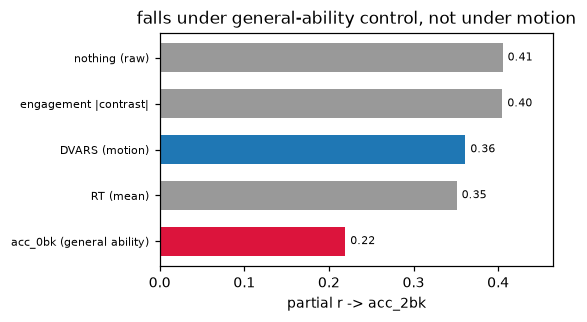

In [16]:
# controls ladder -- the effect survives motion but falls under general ability
labs = [n for n, _ in lad][::-1]
vals = [v for _, v in lad][::-1]
cols = ["crimson" if "ability" in n else ("tab:blue" if "DVARS" in n else "0.6") for n in labs]
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.barh(range(len(labs)), vals, color=cols, height=0.62)
for y, v in zip(range(len(labs)), vals): ax.text(v+0.006, y, f"{v:.2f}", va="center", fontsize=7)
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=7.5)
ax.set(xlabel="partial r -> acc_2bk", xlim=(0, max(vals)+0.06),
       title="falls under general-ability control, not under motion")
plt.tight_layout(); plt.show()

Controlling baseline ability (`acc_0bk`): the effect is attenuated but not eliminated — partial
r ≈ 0.22 (acc_2bk) and ≈ 0.24 (d′), comparable.

- The signal is **not purely general ability**, and d′ is **not** dramatically more robust here.
- d′ is preferred as the primary target on **measurement grounds** (it separates sensitivity from response bias).

### 3d. Motion and age

Motion is a real but small confound and does not drive the effect. Age is not in the curated set.

In [17]:
# motion does not drive it: the FC features barely encode DVARS, and the effect survives removing it
r_fp_dvars = pearsonr(cv_predict(Xb, dvars, crystal_ball), dvars)[0]
Xr = np.column_stack([residualize(Xb[:, k], dvars) for k in range(Xb.shape[1])])
yr = residualize(y_acc, dvars)
print(f"corr(DVARS, acc_2bk)                 = {pearsonr(dvars, y_acc)[0]:+.3f}   (real but modest)")
print(f"engagement |contrast| -> acc_2bk     = {pearsonr(engage, y_acc)[0]:+.3f}   (~0, the old control was vacuous)")
print(f"fingerprint predicts DVARS? CV r     = {r_fp_dvars:+.3f}   (features barely encode motion)")
print(f"effect with DVARS residualised out   = {pearsonr(cv_predict(Xr, yr, crystal_ball), yr)[0]:+.3f}")

# age: confirm the curated demographics carry nothing interpretable
demo_path = B.behaviour.parent.parent / "pseudo_demographics.npy"
if demo_path.exists():
    demo = np.asarray(np.load(demo_path, allow_pickle=True), dtype=float)
    print(f"pseudo_demographics {demo.shape}: columns z-scored, means ~0 "
          f"({np.all(np.abs(np.nanmean(demo, 0)) < 0.15)}) -> no interpretable age")
else:
    print("pseudo_demographics.npy not present")

corr(DVARS, acc_2bk)                 = -0.232   (real but modest)
engagement |contrast| -> acc_2bk     = +0.038   (~0, the old control was vacuous)
fingerprint predicts DVARS? CV r     = +0.038   (features barely encode motion)


effect with DVARS residualised out   = +0.350
pseudo_demographics (339, 25): columns z-scored, means ~0 (True) -> no interpretable age


## 4. Direction: integration or segregation

The primary test is non-directional, but the pod needs a direction. Two questions, from the same
condition FC: does individual reconfiguration toward integration predict performance, and does a
graph segregation metric (Newman modularity) predict at all?

In [18]:
# per-subject within/between-network FC and modularity Q (fixed 12-network partition), each condition
same = (net_b[:, None] == net_b[None, :])
iu = np.triu_indices(360, k=1)
within_e, between_e = same[iu], ~same[iu]

def modularity_Q(fc):
    A = np.where(fc > 0, fc, 0.0); np.fill_diagonal(A, 0.0)
    k = A.sum(1); m2 = A.sum()
    return (A - np.outer(k, k) / m2)[same].sum() / m2   # Newman Q with the fixed partition

W, Bt, Q = {}, {}, {}
for lvl in ("0back", "2back"):
    w, b, q = [], [], []
    for s in subs_b:
        fc = np.corrcoef(condition_signals(B, s, lvl)); e = fc[iu]
        w.append(e[within_e].mean()); b.append(e[between_e].mean()); q.append(modularity_Q(fc))
    W[lvl], Bt[lvl], Q[lvl] = np.array(w), np.array(b), np.array(q)

integration = Bt["2back"] - Bt["0back"]                 # + = between-network FC rises under load
print("group-level 2bk vs 0bk (mean over subjects):")
print(f"  within-FC {W['2back'].mean()-W['0back'].mean():+.4f}   between-FC {integration.mean():+.4f}   "
      f"modularity {Q['2back'].mean()-Q['0back'].mean():+.4f}   -> load shifts toward integration (tiny)")

ri, pi = pearsonr(integration, y_acc)
rq, pq = pearsonr(Q["0back"], y_acc)
rng = np.random.default_rng(0); obs = abs(rq)
nd = np.array([abs(pearsonr(Q["0back"], rng.permutation(y_acc))[0]) for _ in range(2000)])
print("\nindividual differences -> acc_2bk:")
print(f"  integration index          r = {ri:+.3f} (p = {pi:.2f})   -> not a predictor")
print(f"  baseline modularity Q(0bk) r = {rq:+.3f} (p = {pq:.1e})   "
      f"partial|acc_0bk = {partial_r(Q['0back'], y_acc, acc0):+.3f}   null p = {(nd >= obs).mean():.4f}")

group-level 2bk vs 0bk (mean over subjects):
  within-FC -0.0052   between-FC +0.0026   modularity -0.0052   -> load shifts toward integration (tiny)



individual differences -> acc_2bk:
  integration index          r = +0.043 (p = 0.43)   -> not a predictor
  baseline modularity Q(0bk) r = +0.180 (p = 9.3e-04)   partial|acc_0bk = +0.128   null p = 0.0005


- **Load nudges the group toward integration**, but *individual* integration does not predict performance (r ≈ 0.04).
- **What predicts is baseline segregation:** modularity at 0-back correlates with performance (r ≈ 0.18), survives the ability control, and beats the null.
- **Direction — segregation-maintenance (Chan 2014; Wig 2017; Calder 2026), but by analogy only.** Those are resting-state within/between edge-fraction system segregation (Chan SS); our 0-back is a low-load *task* condition scored with Newman modularity. Read it as **baseline task modularity** (a low-load task analogue of resting segregation), weakly linked to cognition in the direction the rest literature reports.
- More interpretable than the 78-dim fingerprint; a candidate for the graph-theory layer.
- *(B also ships resting-state runs, so anchoring the analogy to actual rest is a possible extension, not MVP.)*

reconciliation numbers (out-of-sample r -> acc_2bk):
  0back     repeated-CV +0.274 +/- 0.032 | cross-run +0.288
  2back     repeated-CV +0.260 +/- 0.030 | cross-run +0.238
  reconfig  repeated-CV +0.366 +/- 0.024 | cross-run +0.280
  integration index (scalar)          +0.043


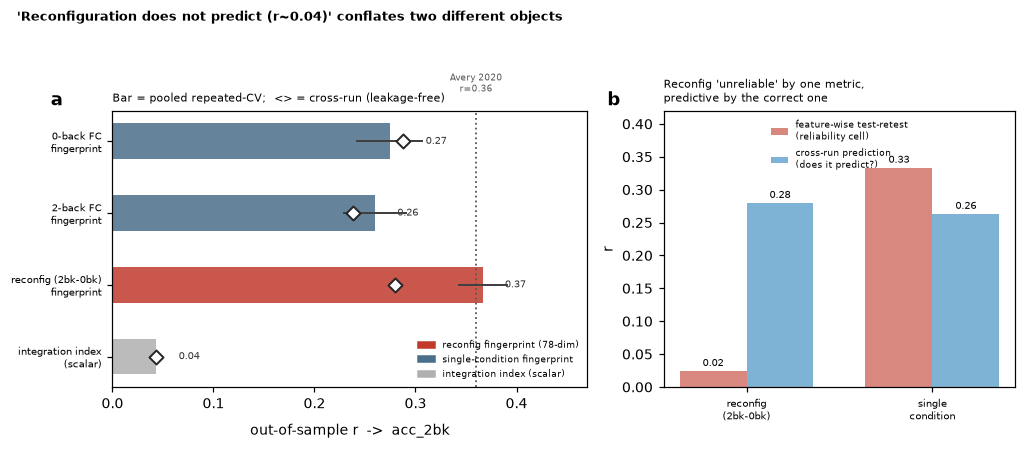

In [19]:
# ADDED 2026-07-17 (post-audit): reconciliation figure for the P0 framing fix.
# "Reconfiguration does not predict (r~0.04)" conflated two objects: the 78-dim multivariate fingerprint
# (predicts) vs the scalar integration index (does not). Panel (a) puts the four objects on one axis;
# panel (b) shows the reconfig's two "reliabilities" giving opposite verdicts. Reuses _fp (section 3b),
# fps (section 3a), integration (section 4), _cross_run_r (section 3b) -- all defined above.
from matplotlib.patches import Patch

def _repcv(X, n=20):
    return np.array([pearsonr(cv_predict(X, y_acc, crystal_ball, seed=s), y_acc)[0] for s in range(n)])

rep = {k: _repcv(fps[k]) for k in ("0back", "2back", "reconfig")}
xr  = {k: float(np.mean(_cross_run_r(k))) for k in ("0back", "2back", "reconfig")}
ri  = pearsonr(integration, y_acc)[0]           # integration index (scalar), from section 4

print("reconciliation numbers (out-of-sample r -> acc_2bk):")
for k in ("0back", "2back", "reconfig"):
    print(f"  {k:9s} repeated-CV {rep[k].mean():+.3f} +/- {rep[k].std():.3f} | cross-run {xr[k]:+.3f}")
print(f"  integration index (scalar)          {ri:+.3f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.4, 4.0), gridspec_kw={"width_ratios": [1.35, 1]})
labels = ["0-back FC\nfingerprint", "2-back FC\nfingerprint", "reconfig (2bk-0bk)\nfingerprint", "integration index\n(scalar)"]
mean_r = [rep["0back"].mean(), rep["2back"].mean(), rep["reconfig"].mean(), ri]
std_r  = [rep["0back"].std(),  rep["2back"].std(),  rep["reconfig"].std(),  0.0]
cross_r= [xr["0back"], xr["2back"], xr["reconfig"], ri]
cols   = ["#4a6f8a", "#4a6f8a", "#c0392b", "#b0b0b0"]
yy = np.arange(len(labels))[::-1]
for yi, m, s, cr, col in zip(yy, mean_r, std_r, cross_r, cols):
    axA.barh(yi, m, height=0.5, color=col, alpha=0.85, zorder=2)
    if s > 0: axA.plot([m-s, m+s], [yi, yi], color="0.25", lw=1.3, zorder=4)
    axA.scatter(cr, yi, marker="D", s=42, facecolor="white", edgecolor="0.15", lw=1.3, zorder=5)
    axA.text(max(m, cr)+0.022, yi, f"{m:.2f}", va="center", fontsize=6.5, color="0.2")
axA.axvline(0.36, color="0.35", ls=":", lw=1.2)
axA.text(0.36, len(labels)-0.35, "Avery 2020\nr=0.36", fontsize=6, color="0.35", ha="center", va="bottom")
axA.set_yticks(yy); axA.set_yticklabels(labels, fontsize=6.8)
axA.set_xlim(0, 0.47); axA.set_xlabel("out-of-sample r  ->  acc_2bk", labelpad=8)
axA.set_title("Bar = pooled repeated-CV;  <> = cross-run (leakage-free)", fontsize=7.2, loc="left")
axA.legend(handles=[Patch(color="#c0392b", label="reconfig fingerprint (78-dim)"),
                    Patch(color="#4a6f8a", label="single-condition fingerprint"),
                    Patch(color="#b0b0b0", label="integration index (scalar)")],
           loc="lower right", fontsize=5.8, frameon=False)
axA.text(-0.13, 1.02, "a", transform=axA.transAxes, fontsize=12, fontweight="bold")

x = np.arange(2); w = 0.36
fw = [0.024, 0.333]; cp = [xr["reconfig"], (xr["0back"]+xr["2back"])/2]   # feature-wise vs cross-run
axB.bar(x-w/2, fw, w, color="#d98880", label="feature-wise test-retest\n(reliability cell)")
axB.bar(x+w/2, cp, w, color="#7fb3d5", label="cross-run prediction\n(does it predict?)")
for xi, v in zip(x-w/2, fw): axB.text(xi, v+0.008, f"{v:.02f}", ha="center", fontsize=6.3)
for xi, v in zip(x+w/2, cp): axB.text(xi, v+0.008, f"{v:.2f}", ha="center", fontsize=6.3)
axB.set_xticks(x); axB.set_xticklabels(["reconfig\n(2bk-0bk)", "single\ncondition"], fontsize=6.8)
axB.set_ylim(0, 0.42); axB.set_ylabel("r")
axB.set_title("Reconfig 'unreliable' by one metric,\npredictive by the correct one", fontsize=7.2, loc="left")
axB.legend(loc="upper center", fontsize=5.8, frameon=False)
axB.text(-0.16, 1.02, "b", transform=axB.transAxes, fontsize=12, fontweight="bold")
fig.suptitle("'Reconfiguration does not predict (r~0.04)' conflates two different objects",
             fontsize=8.6, y=1.005, x=0.02, ha="left", weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## 5. The d' correction

The correction is not arbitrary. HCP WM has 2 target and 8 non-target trials per block; over 4
categories and 2 runs that is 16 and 64, so the clips 1/32 and 1/128 are exactly the 1/2N rule, and
clip vs loglinear give near-identical d'.

In [20]:
N_TARGET, N_NONTARGET = 16, 64
assert abs(1/32  - 1/(2*N_TARGET))    < 1e-9      # clip hit = 1/(2*N_target)
assert abs(1/128 - 1/(2*N_NONTARGET)) < 1e-9      # clip fa  = 1/(2*N_nontarget)

sd = pp.signal_detection_table(B).set_index("subject").loc[subs_b]
hit, fa = sd["hit_2bk"].to_numpy(float), sd["fa_2bk"].to_numpy(float)
d_loglinear = (norm.ppf((hit*N_TARGET + 0.5)/(N_TARGET + 1))
               - norm.ppf((fa*N_NONTARGET + 0.5)/(N_NONTARGET + 1)))
print(f"d' clip vs loglinear: corr = {pearsonr(y_dp, d_loglinear)[0]:.4f}  "
      f"(means {y_dp.mean():.3f} vs {d_loglinear.mean():.3f})")
print(f"subjects at hit == 1.0 (need the clip): {(hit >= 0.999).sum()}/{len(hit)}")

d' clip vs loglinear: corr = 0.9973  (means 2.128 vs 2.027)
subjects at hit == 1.0 (need the clip): 34/336


## 6. Multiple comparisons

The four tests in section 2 (2 methods x 2 targets) are not independent: acc and d' are nearly the
same target, and the two methods' predictions correlate highly. Read as one family, about 1.5
effective looks. All are p < 0.001, so they clear Bonferroni regardless.

In [21]:
def getpred(data, method, target):
    return next(r["pred"] for r in rows if r["data"]==data and r["method"]==method and r["target"]==target)
pa_fp, pa_tr, pd_fp = getpred("B","fingerprint","acc"), getpred("B","triple-network","acc"), getpred("B","fingerprint","dprime")
print(f"corr(acc_2bk, d')                         = {pearsonr(y_acc, y_dp)[0]:.3f}")
print(f"corr(pred fingerprint/acc, pred triple/acc) = {pearsonr(pa_fp, pa_tr)[0]:.3f}")
print(f"corr(pred fingerprint/acc, pred fingerprint/d') = {pearsonr(pa_fp, pd_fp)[0]:.3f}")
print("-> ~1.5 effective tests, not 4.")

corr(acc_2bk, d')                         = 0.945
corr(pred fingerprint/acc, pred triple/acc) = 0.383
corr(pred fingerprint/acc, pred fingerprint/d') = 0.973
-> ~1.5 effective tests, not 4.


In [22]:
# ADDED 2026-07-17 (post-audit): why r=-0.015 on A (n=100) but 0.405 on B (n=336)? Power, not cohort.
# Subsample B down to A's n=100 and re-run the SAME reconfig-fingerprint pipeline over 30 draws.
_rng = np.random.default_rng(0)
_subr = []
for _ in range(30):
    _idx = _rng.choice(len(subs_b), 100, replace=False)
    _subr.append(pearsonr(cv_predict(Xb[_idx], y_acc[_idx], crystal_ball), y_acc[_idx])[0])
_subr = np.array(_subr)
print(f"B subsampled to n=100 (reconfig fingerprint), 30 draws: r = {_subr.mean():.3f} +/- {_subr.std():.3f}  "
      f"[{_subr.min():.2f}, {_subr.max():.2f}]")
print("  -> brackets dataset A's r=-0.015; A's null is a power/estimation-stability artifact, not a cohort difference")
# expected: ~0.08 +/- 0.15, range roughly [-0.21, 0.40]

B subsampled to n=100 (reconfig fingerprint), 30 draws: r = 0.078 +/- 0.146  [-0.21, 0.40]
  -> brackets dataset A's r=-0.015; A's null is a power/estimation-stability artifact, not a cohort difference


## 7. Limitations and conclusion

**What we can claim**
- Reproduces Goutham's dataset-A numbers exactly (§1).
- On B, the same pipeline predicts 2-back accuracy in held-out subjects: **repeated-CV r ~0.37 ± 0.02** (single held-out 0.31; seed-42 0.41 is one optimistic draw), **p < 0.001** vs the permutation null, robust to a DVARS motion proxy (parcellated BOLD; FD unavailable in the curated set).
- **Consistent with Avery 2020** (r = 0.36, same HCP N-back task and target; different model — their 10-fold-CV CPM vs our 5-fold RidgeCV over 78 network summaries). Avery's *undifferenced* whole-task FC analog is repeated-CV r ~0.28 (§3a).
- A conceptual replication, not a new predictive result.

**Main finding — a pattern-vs-scalar dissociation in the load reconfiguration**
- The **multivariate 2bk-0bk fingerprint DOES predict** (repeated-CV r ~0.37; leakage-free cross-run r ~0.28, §3b). Single-condition trait FC also predicts (0bk-only repeated-CV r ~0.27).
- **What does not predict:** the scalar directional summaries — net between-network integration index (r ~0.04, §4) and mean modularity change.
- **Why the scalars fail, not the pattern:** subtracting two correlated conditions destroys the shared true-score variance a single scalar contrast needs (difference-score psychometrics, Hedge 2018), so the index barely moves with performance; a multivariate model instead aggregates weak-but-consistent signal across 78 edges. Feature-wise unreliability (r ~0.02, §3b) does not carry to the pattern.
- **Largely trait / general ability:** controlling `acc_0bk` attenuates to a comparable partial r ~0.22 (acc_2bk) / ~0.24 (d'), reduced but not eliminated. d' is the primary target on measurement grounds (sensitivity vs response bias), not because it is more robust here.

**Limitations**
- **Stability vs n:** the 78-feature fingerprint needs large n. Subsampling B to n=100 gives r ~0.08 ± 0.15, bracketing dataset A's r ~-0.015 (§7 cell) — A's null is a power/estimation artifact, not a cohort difference.
- **Static FC:** timepoints averaged within condition; dynamic FC (CAPs / k-means, not a full HMM) is the declared team extension, out of MVP scope.
- **Direction:** individual integration does not predict; only baseline 0-back modularity does, weakly (r ~0.18) — a partial task analogue of resting system segregation (Chan 2014; Wig 2017; Calder 2026).
- **Same-task prediction** (2bk FC → 2bk accuracy): accepted but partly inflated by shared task engagement; d' (net of response bias) is a partial guard.
- **Confounds:** motion enters only via a DVARS proxy (no FD or motion parameters in the curated set); no real age/sex and no family IDs, so family-structure leakage cannot be modelled (expected inflation small — Rosenblatt 2024, dr ≤ ~0.02). Graph metrics beyond modularity untried.

**Conclusion — an honest dissociation**
- FC predicts WM in unseen subjects (repeated-CV r ~0.37, p < 0.001, robust to a DVARS proxy, consistent with Avery 2020), and the **multivariate load-reconfiguration pattern predicts too** (cross-run r ~0.28).
- Its **scalar directional summaries do not** (integration index, mean modularity change) — a pattern-vs-scalar dissociation explained by difference-score reliability.
- **Report:** accuracy first (comparable to Avery), d' as the measurement-clean primary target, baseline segregation as the weak interpretable direction.
- Deliverable: the reconfiguration *pattern* carries individual predictive signal; its *one-number* directional summaries do not.